# Bag of Words Classifier

This notebook shows a simple sentiment classifier using Bag of Words and a neural network.

## 1. Import libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from tqdm import tqdm
import re

## 2. Load and preprocess data

In [2]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d', ' ', text)
    return text.strip()

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")

train_texts = [preprocess_text(t) for t in ds['train']['text']]
test_texts = [preprocess_text(t) for t in ds['test']['text']]
train_labels = ds['train']['label']
test_labels = ds['test']['label']

## 3. Build vocabulary
Create a dictionary of all unique words from training reviews.

In [10]:
def build_vocab(texts):
    vocab = {}
    idx = 0
    for sentence in texts:
        for word in sentence.split():
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    return vocab

vocab = build_vocab(train_texts)
print(f'Word count in vocabulary: {len(vocab)}')

Word count in vocabulary: 16351


## 4. Convert reviews to Bag of Words vectors
Transform each review into a Bag of Words vector using the vocabulary.

In [14]:
def text_to_bow(text, vocab):
    vec = np.zeros(len(vocab), dtype=np.float32)
    for word in text.split():
        if word in vocab:
            idx = vocab[word]
            vec[idx] += 1
    return vec

X_train = np.array([text_to_bow(text, vocab) for text in train_texts])
X_test = np.array([text_to_bow(text, vocab) for text in test_texts])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(f'BoW vector example: {X_train[0][:10]}')

BoW vector example: [2. 1. 1. 1. 2. 1. 1. 1. 2. 1.]


## 5. Define model
Simple model: one linear layer and sigmoid activation.

In [16]:
class BoWClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

input_dim = X_train.shape[1]
model = BoWClassifier(input_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

cuda


## 6. Training
Train the model using binary cross-entropy loss.

In [20]:
lr = 0.01
epochs = 15
batch_size = 64
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.BCELoss()
model.to(device)

accuracy_list = []
for epoch in tqdm(range(epochs)):
    model.train()
    permutation = torch.randperm(X_train_tensor.size()[0])
    for i in range(0, X_train_tensor.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        preds = (test_outputs > 0.5).float()
        acc = (preds == y_test_tensor).float().mean().item()
        accuracy_list.append(acc)
    print(f'Epoch {epoch+1}/{epochs}, Accuracy: {acc:.4f}')

 20%|██        | 3/15 [00:01<00:03,  3.40it/s]

Epoch 1/15, Accuracy: 0.7833
Epoch 2/15, Accuracy: 0.7936
Epoch 3/15, Accuracy: 0.7936


 33%|███▎      | 5/15 [00:01<00:01,  5.53it/s]

Epoch 4/15, Accuracy: 0.7899
Epoch 5/15, Accuracy: 0.7908
Epoch 6/15, Accuracy: 0.7889
Epoch 7/15, Accuracy: 0.7899


 60%|██████    | 9/15 [00:01<00:00,  9.04it/s]

Epoch 8/15, Accuracy: 0.7861
Epoch 9/15, Accuracy: 0.7842
Epoch 10/15, Accuracy: 0.7824


 87%|████████▋ | 13/15 [00:01<00:00, 11.29it/s]

Epoch 11/15, Accuracy: 0.7871
Epoch 12/15, Accuracy: 0.7833
Epoch 13/15, Accuracy: 0.7852


100%|██████████| 15/15 [00:01<00:00,  7.74it/s]

Epoch 14/15, Accuracy: 0.7861
Epoch 15/15, Accuracy: 0.7908


## 7. Accuracy plot
Plot test accuracy over epochs.

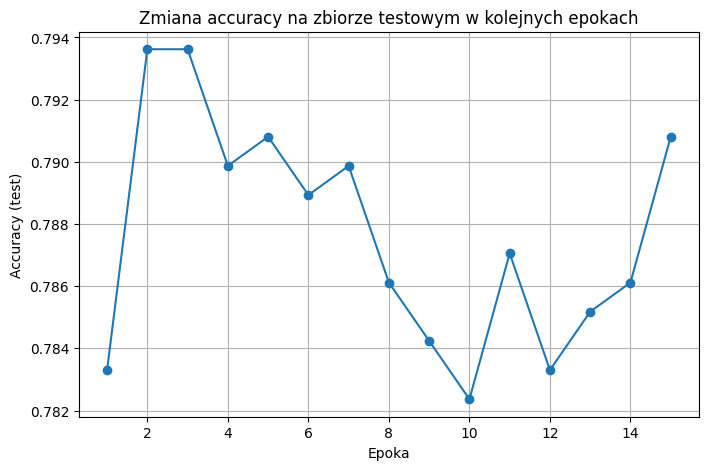

In [21]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(accuracy_list)+1), accuracy_list, marker='o')
plt.xlabel('Epoka')
plt.ylabel('Accuracy (test)')
plt.title('Zmiana accuracy na zbiorze testowym w kolejnych epokach')
plt.grid(True)
plt.show()

## 8. Results
The plot shows how test accuracy changes during training. The model improves, but Bag of Words is limited since it ignores word order and context.